# Aula de Linha de Regressão — Trabalho Completo
### Comparação: Regressão Linear × SVM × GPR
**Dataset:** Iris | **Alvo:** Predição de Petal Width a partir de Petal Length

---
## PARTE 1 — Código original do professor (mantido sem alterações)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Novas importações para SVM, GPR e utilitários
import numpy as np
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

import time

Importando dataset iris do conjunto de datasets salvos no SKlearn

In [2]:
#df = pd.read_csv('iris.csv', sep=',') Essa eh a forma manual
iris = datasets.load_iris()

In [3]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [4]:
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Criando subplot para testar a distribuição dos elementos

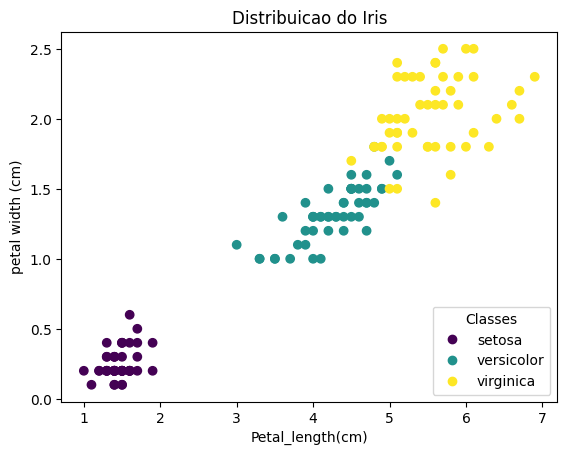

In [5]:
fig, ax = plt.subplots()
scatter = ax.scatter(iris.data[:,2], iris.data[:,3], c=iris.target)
ax.set_title('Distribuicao do Iris')
ax.set_xlabel('Petal_length(cm)')
#ax.set_ylabel('Petal_width(cm)') #opção tradicional
ax.set_ylabel(iris.feature_names[3]) #outra opção
ax.legend(scatter.legend_elements()[0], iris.target_names,
           loc="lower right", title="Classes")
plt.show()

Regressão Linear

In [6]:
X = iris.data[:,2].reshape(-1, 1) #petal_length
y = iris.data[:,3] #petal_width
especie = iris.target

In [7]:
print(X)

[[1.4]
 [1.4]
 [1.3]
 [1.5]
 [1.4]
 [1.7]
 [1.4]
 [1.5]
 [1.4]
 [1.5]
 [1.5]
 [1.6]
 [1.4]
 [1.1]
 [1.2]
 [1.5]
 [1.3]
 [1.4]
 [1.7]
 [1.5]
 [1.7]
 [1.5]
 [1. ]
 [1.7]
 [1.9]
 [1.6]
 [1.6]
 [1.5]
 [1.4]
 [1.6]
 [1.6]
 [1.5]
 [1.5]
 [1.4]
 [1.5]
 [1.2]
 [1.3]
 [1.4]
 [1.3]
 [1.5]
 [1.3]
 [1.3]
 [1.3]
 [1.6]
 [1.9]
 [1.4]
 [1.6]
 [1.4]
 [1.5]
 [1.4]
 [4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]
 [4.5]
 [4.7]
 [3.3]
 [4.6]
 [3.9]
 [3.5]
 [4.2]
 [4. ]
 [4.7]
 [3.6]
 [4.4]
 [4.5]
 [4.1]
 [4.5]
 [3.9]
 [4.8]
 [4. ]
 [4.9]
 [4.7]
 [4.3]
 [4.4]
 [4.8]
 [5. ]
 [4.5]
 [3.5]
 [3.8]
 [3.7]
 [3.9]
 [5.1]
 [4.5]
 [4.5]
 [4.7]
 [4.4]
 [4.1]
 [4. ]
 [4.4]
 [4.6]
 [4. ]
 [3.3]
 [4.2]
 [4.2]
 [4.2]
 [4.3]
 [3. ]
 [4.1]
 [6. ]
 [5.1]
 [5.9]
 [5.6]
 [5.8]
 [6.6]
 [4.5]
 [6.3]
 [5.8]
 [6.1]
 [5.1]
 [5.3]
 [5.5]
 [5. ]
 [5.1]
 [5.3]
 [5.5]
 [6.7]
 [6.9]
 [5. ]
 [5.7]
 [4.9]
 [6.7]
 [4.9]
 [5.7]
 [6. ]
 [4.8]
 [4.9]
 [5.6]
 [5.8]
 [6.1]
 [6.4]
 [5.6]
 [5.1]
 [5.6]
 [6.1]
 [5.6]
 [5.5]
 [4.8]
 [5.4]
 [5.6]
 [5.1]
 [5.1]

In [8]:
print(iris.data[:,2])

[1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 1.5 1.6 1.4 1.1 1.2 1.5 1.3 1.4
 1.7 1.5 1.7 1.5 1.  1.7 1.9 1.6 1.6 1.5 1.4 1.6 1.6 1.5 1.5 1.4 1.5 1.2
 1.3 1.4 1.3 1.5 1.3 1.3 1.3 1.6 1.9 1.4 1.6 1.4 1.5 1.4 4.7 4.5 4.9 4.
 4.6 4.5 4.7 3.3 4.6 3.9 3.5 4.2 4.  4.7 3.6 4.4 4.5 4.1 4.5 3.9 4.8 4.
 4.9 4.7 4.3 4.4 4.8 5.  4.5 3.5 3.8 3.7 3.9 5.1 4.5 4.5 4.7 4.4 4.1 4.
 4.4 4.6 4.  3.3 4.2 4.2 4.2 4.3 3.  4.1 6.  5.1 5.9 5.6 5.8 6.6 4.5 6.3
 5.8 6.1 5.1 5.3 5.5 5.  5.1 5.3 5.5 6.7 6.9 5.  5.7 4.9 6.7 4.9 5.7 6.
 4.8 4.9 5.6 5.8 6.1 6.4 5.6 5.1 5.6 6.1 5.6 5.5 4.8 5.4 5.6 5.1 5.1 5.9
 5.7 5.2 5.  5.2 5.4 5.1]


Fazendo train teste split tradicional com elemento de especie

In [9]:
X_treino, X_teste, y_treino, y_teste, especie_treino, especie_teste = train_test_split(X, y, especie, test_size=0.2, random_state=40)

Treinando o modelo

In [10]:
regressao = linear_model.LinearRegression()
regressao.fit(X_treino, y_treino)
y_pred = regressao.predict(X_teste)

Gerando resultado

In [11]:
r2 = r2_score(y_teste, y_pred)
mse = mean_squared_error(y_teste, y_pred)
rmse = mse ** 0.5
print (r2, mse, rmse)

0.9301094595331071 0.039918370468446235 0.19979582194942475


Criando máscara

In [12]:
setosa = especie_teste == 0 
versicolor = especie_teste == 1 
virginica = especie_teste == 2

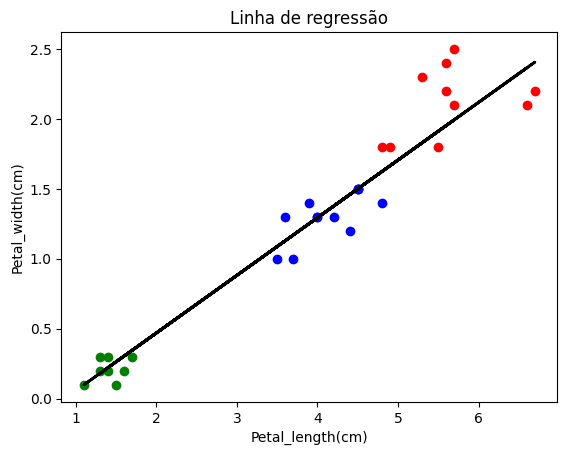

In [13]:
plt.scatter(X_teste[setosa], y_teste[setosa], 
            color='green', label='setosa')
plt.scatter(X_teste[versicolor], y_teste[versicolor], 
            color='blue', label='versicolor')
plt.scatter(X_teste[virginica], y_teste[virginica], 
            color='red', label='virginica')
plt.plot(X_teste, y_pred, color='black', linewidth=2, 
         label='Linha de Regressão')
plt.xlabel('Petal_length(cm)')
plt.ylabel('Petal_width(cm)')
plt.title('Linha de regressão')
plt.show()

---
## PARTE 2 — SVM (Support Vector Machine para Regressão)

O SVM para regressão (SVR) encontra uma função que se aproxima dos dados dentro de uma margem de tolerância ε (epsilon). Ao contrário da Regressão Linear que minimiza todos os erros, o SVR ignora erros menores que epsilon e penaliza apenas os que ultrapassam essa margem. Com `kernel='rbf'`, ele consegue capturar relações **não-lineares** nos dados.

In [14]:
# Treinando o modelo SVM (SVR = Support Vector Regression)
# kernel='rbf'  → função de base radial (gaussiana): captura relações não-lineares
# C=1.0         → penalidade para erros fora da margem: maior C = menos tolerância a erros = mais flexível
# epsilon=0.1   → margem de tolerância: erros menores que isso são ignorados pelo modelo
svm = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svm.fit(X_treino, y_treino)
y_pred_svm = svm.predict(X_teste)

In [15]:
# Gerando resultado SVM — mesmo padrão do professor
r2_svm   = r2_score(y_teste, y_pred_svm)
mse_svm  = mean_squared_error(y_teste, y_pred_svm)
rmse_svm = mse_svm ** 0.5
mae_svm  = np.mean(np.abs(y_teste - y_pred_svm))
print('SVM — R²:', r2_svm, '| MSE:', mse_svm, '| RMSE:', rmse_svm, '| MAE:', mae_svm)

SVM — R²: 0.9486179427140964 | MSE: 0.029347147474717665 | RMSE: 0.17131009157290666 | MAE: 0.13230924194453159


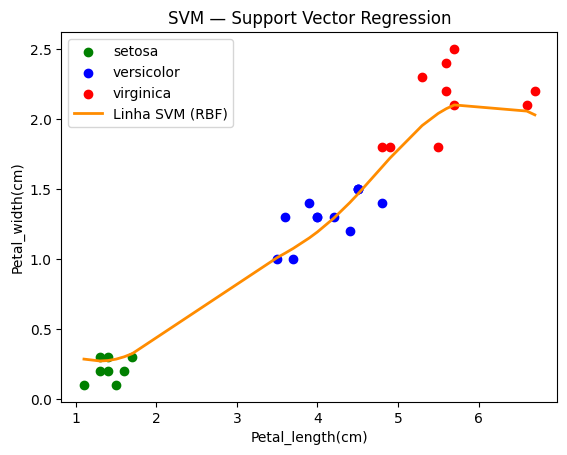

In [16]:
# Gráfico SVM — mesmo estilo do professor
# Ordenar X_teste para que a curva seja suave (necessário pois SVM é não-linear)
ordem_svm = X_teste[:,0].argsort()

plt.scatter(X_teste[setosa], y_teste[setosa], 
            color='green', label='setosa')
plt.scatter(X_teste[versicolor], y_teste[versicolor], 
            color='blue', label='versicolor')
plt.scatter(X_teste[virginica], y_teste[virginica], 
            color='red', label='virginica')
plt.plot(X_teste[ordem_svm], y_pred_svm[ordem_svm], color='darkorange', linewidth=2, 
         label='Linha SVM (RBF)')
plt.xlabel('Petal_length(cm)')
plt.ylabel('Petal_width(cm)')
plt.title('SVM — Support Vector Regression')
plt.legend()
plt.show()

---
## PARTE 3 — GPR (Gaussian Process Regression)

O GPR é um método probabilístico: em vez de retornar apenas um valor previsto, ele retorna uma **distribuição** — ou seja, fornece a previsão **e** a incerteza associada. O kernel define como a similaridade entre pontos é calculada. Com `RBF`, pontos próximos têm previsões similares. O GPR é especialmente poderoso porque calibra sua confiança: incerto onde há poucos dados, confiante onde há muitos.

In [17]:
# Treinando o modelo GPR (Gaussian Process Regression)
# C(1.0, (1e-3, 1e3))         → amplitude da função (escala vertical dos dados)
# RBF(length_scale=1.0, ...)  → kernel de suavidade: define quão suave é a curva
#                               length_scale pequeno = mais rugoso, grande = mais suave
# alpha=1e-10                 → regularização numérica para estabilidade da matriz
# n_restarts_optimizer=10     → busca o melhor kernel automaticamente em 10 tentativas
kernel_gpr = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gpr = GaussianProcessRegressor(kernel=kernel_gpr, alpha=1e-10, n_restarts_optimizer=10)
gpr.fit(X_treino, y_treino)
y_pred_gpr, sigma = gpr.predict(X_teste, return_std=True)  # return_std=True retorna a incerteza

d:\Projetos\GitHub\UFPA\transistor-de-fronteira-camtuc\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
d:\Projetos\GitHub\UFPA\transistor-de-fronteira-camtuc\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Projetos\GitHub\UFPA\transistor-de-fronteira-camtuc\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit ag

In [18]:
# Gerando resultado GPR — mesmo padrão do professor
r2_gpr   = r2_score(y_teste, y_pred_gpr)
mse_gpr  = mean_squared_error(y_teste, y_pred_gpr)
rmse_gpr = mse_gpr ** 0.5
mae_gpr  = np.mean(np.abs(y_teste - y_pred_gpr))
print('GPR — R²:', r2_gpr, '| MSE:', mse_gpr, '| RMSE:', rmse_gpr, '| MAE:', mae_gpr)

GPR — R²: 0.5293604464675696 | MSE: 0.26880839566423387 | RMSE: 0.5184673525538844 | MAE: 0.2731165192167284


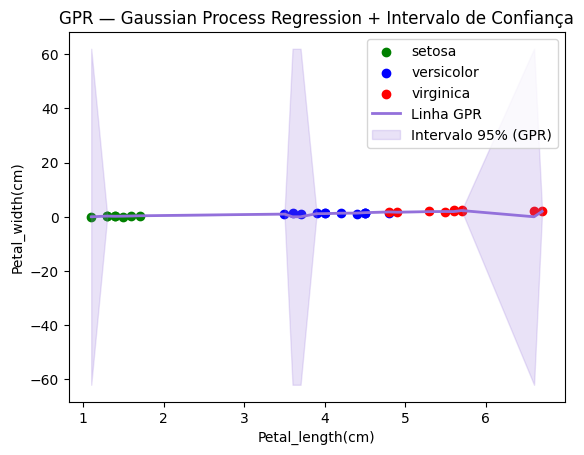

In [19]:
# Gráfico GPR com intervalo de confiança — diferencial do GPR
# Ordenar X_teste para curva suave
ordem_gpr = X_teste[:,0].argsort()
X_ord = X_teste[ordem_gpr]
y_gpr_ord = y_pred_gpr[ordem_gpr]
sigma_ord = sigma[ordem_gpr]

plt.scatter(X_teste[setosa], y_teste[setosa], 
            color='green', label='setosa')
plt.scatter(X_teste[versicolor], y_teste[versicolor], 
            color='blue', label='versicolor')
plt.scatter(X_teste[virginica], y_teste[virginica], 
            color='red', label='virginica')
plt.plot(X_ord, y_gpr_ord, color='mediumpurple', linewidth=2, 
         label='Linha GPR')
# Faixa de confiança: ±1.96 * sigma ≈ intervalo de 95%
plt.fill_between(X_ord[:,0],
                 y_gpr_ord - 1.96 * sigma_ord,
                 y_gpr_ord + 1.96 * sigma_ord,
                 alpha=0.2, color='mediumpurple',
                 label='Intervalo 95% (GPR)')
plt.xlabel('Petal_length(cm)')
plt.ylabel('Petal_width(cm)')
plt.title('GPR — Gaussian Process Regression + Intervalo de Confiança')
plt.legend()
plt.show()

---
## PARTE 4 — Métricas para Regressão Linear (MAE adicionado)

Calculando MAE também para a Regressão Linear, para comparação justa com SVM e GPR.

In [20]:
# Recalculando métricas da Regressão Linear com MAE incluído
r2_lr   = r2_score(y_teste, y_pred)
mse_lr  = mean_squared_error(y_teste, y_pred)
rmse_lr = mse_lr ** 0.5
mae_lr  = np.mean(np.abs(y_teste - y_pred))
print('Regressão Linear — R²:', r2_lr, '| MSE:', mse_lr, '| RMSE:', rmse_lr, '| MAE:', mae_lr)

Regressão Linear — R²: 0.9301094595331071 | MSE: 0.039918370468446235 | RMSE: 0.19979582194942475 | MAE: 0.1459401018760884


---
## PARTE 5 — Gráficos Comparativos de Métricas (R², MAE, RMSE, MSE)

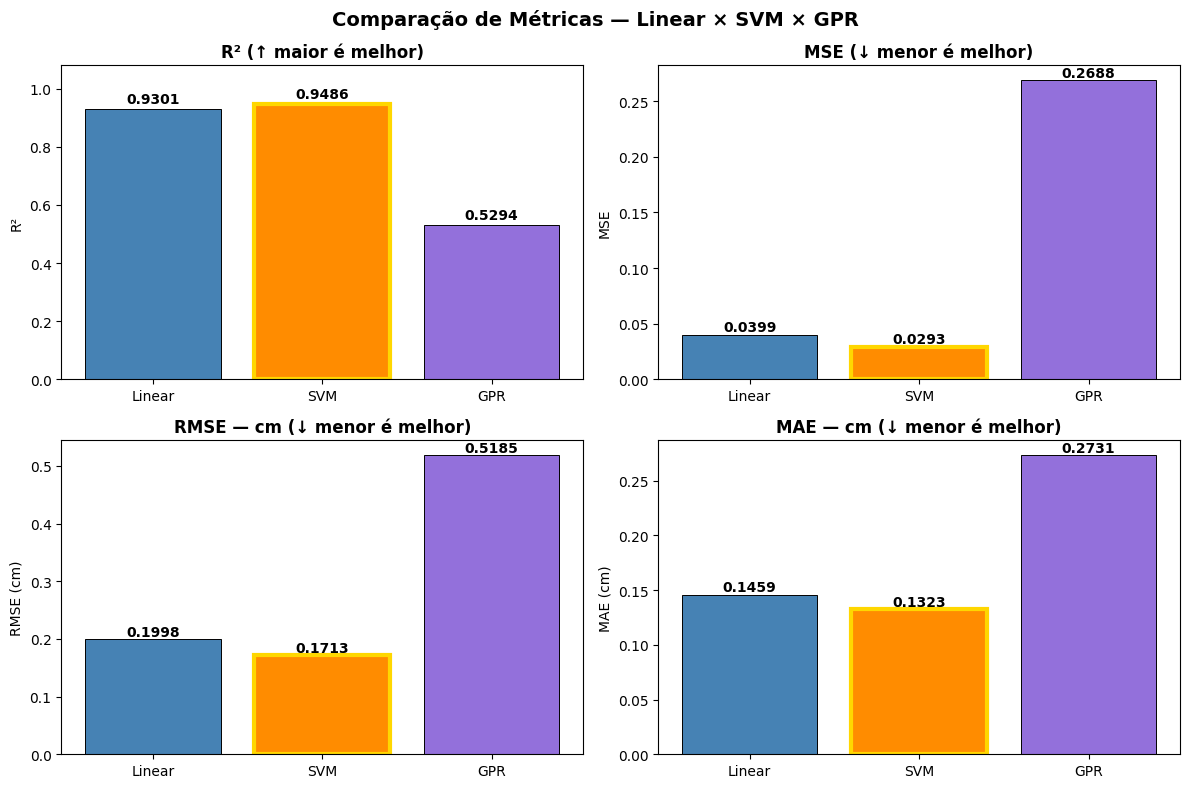

Borda dourada = melhor modelo naquela métrica


In [21]:
# Organizando os valores para plotagem
modelos_nomes = ['Linear', 'SVM', 'GPR']
cores_modelos = ['steelblue', 'darkorange', 'mediumpurple']

valores_r2   = [r2_lr,   r2_svm,   r2_gpr]
valores_mse  = [mse_lr,  mse_svm,  mse_gpr]
valores_rmse = [rmse_lr, rmse_svm, rmse_gpr]
valores_mae  = [mae_lr,  mae_svm,  mae_gpr]

# Painel 2x2 com todas as métricas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Comparação de Métricas — Linear × SVM × GPR', fontsize=14, fontweight='bold')

# R² — quanto maior, melhor
barras = axes[0,0].bar(modelos_nomes, valores_r2, color=cores_modelos, edgecolor='black', linewidth=0.7)
axes[0,0].set_title('R² (↑ maior é melhor)', fontweight='bold')
axes[0,0].set_ylabel('R²')
axes[0,0].set_ylim(0, 1.08)
for barra, v in zip(barras, valores_r2):
    axes[0,0].text(barra.get_x() + barra.get_width()/2, v + 0.01,
                   f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
# Destaque do melhor
melhor_r2 = np.argmax(valores_r2)
barras[melhor_r2].set_edgecolor('gold')
barras[melhor_r2].set_linewidth(3)

# MSE — quanto menor, melhor
barras = axes[0,1].bar(modelos_nomes, valores_mse, color=cores_modelos, edgecolor='black', linewidth=0.7)
axes[0,1].set_title('MSE (↓ menor é melhor)', fontweight='bold')
axes[0,1].set_ylabel('MSE')
for barra, v in zip(barras, valores_mse):
    axes[0,1].text(barra.get_x() + barra.get_width()/2, v + 0.0005,
                   f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
melhor_mse = np.argmin(valores_mse)
barras[melhor_mse].set_edgecolor('gold')
barras[melhor_mse].set_linewidth(3)

# RMSE — quanto menor, melhor
barras = axes[1,0].bar(modelos_nomes, valores_rmse, color=cores_modelos, edgecolor='black', linewidth=0.7)
axes[1,0].set_title('RMSE — cm (↓ menor é melhor)', fontweight='bold')
axes[1,0].set_ylabel('RMSE (cm)')
for barra, v in zip(barras, valores_rmse):
    axes[1,0].text(barra.get_x() + barra.get_width()/2, v + 0.0005,
                   f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
melhor_rmse = np.argmin(valores_rmse)
barras[melhor_rmse].set_edgecolor('gold')
barras[melhor_rmse].set_linewidth(3)

# MAE — quanto menor, melhor
barras = axes[1,1].bar(modelos_nomes, valores_mae, color=cores_modelos, edgecolor='black', linewidth=0.7)
axes[1,1].set_title('MAE — cm (↓ menor é melhor)', fontweight='bold')
axes[1,1].set_ylabel('MAE (cm)')
for barra, v in zip(barras, valores_mae):
    axes[1,1].text(barra.get_x() + barra.get_width()/2, v + 0.0005,
                   f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
melhor_mae = np.argmin(valores_mae)
barras[melhor_mae].set_edgecolor('gold')
barras[melhor_mae].set_linewidth(3)

plt.tight_layout()
plt.savefig('comparativo_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Borda dourada = melhor modelo naquela métrica')

---
## PARTE 6 — Gráfico de Dispersão: Valores Reais × Previstos (3 modelos sobrepostos)

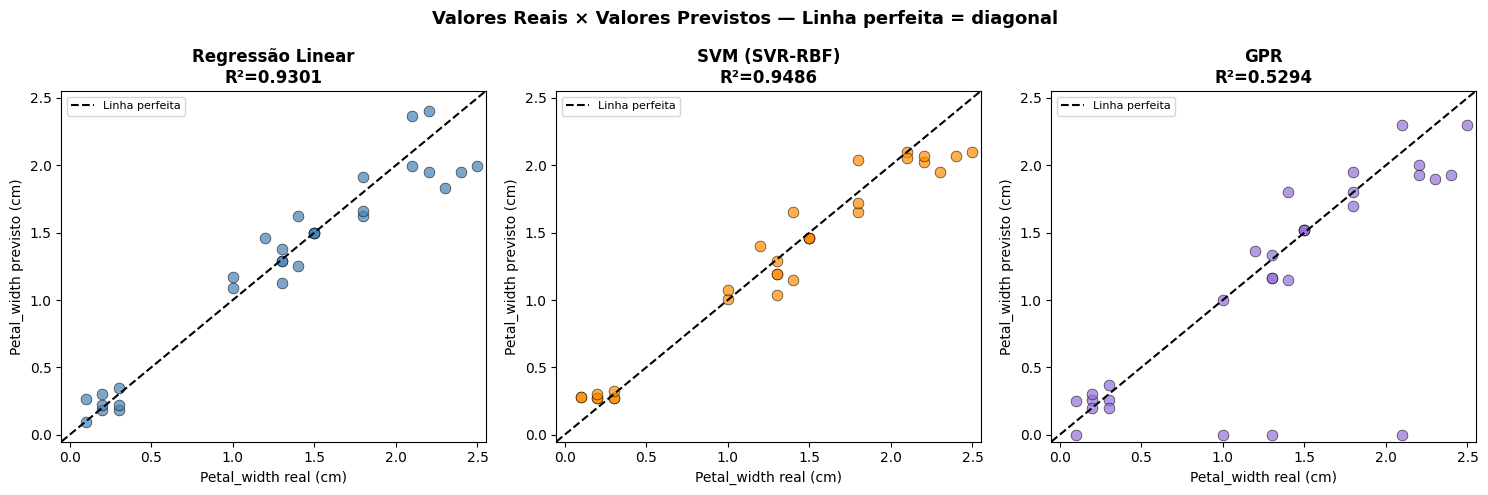

In [22]:
# Gráfico Real × Previsto para os 3 modelos
# Ponto perfeito: todos os pontos na diagonal y=x
# Dispersão ao redor da diagonal = erro do modelo

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Valores Reais × Valores Previstos — Linha perfeita = diagonal', 
             fontsize=13, fontweight='bold')

pares = [
    ('Regressão Linear', y_pred,     'steelblue',    axes[0]),
    ('SVM (SVR-RBF)',    y_pred_svm,  'darkorange',   axes[1]),
    ('GPR',             y_pred_gpr,  'mediumpurple',  axes[2]),
]

lim_min = min(y_teste.min(), y_pred.min(), y_pred_svm.min(), y_pred_gpr.min()) - 0.05
lim_max = max(y_teste.max(), y_pred.max(), y_pred_svm.max(), y_pred_gpr.max()) + 0.05

for nome, y_p, cor, ax in pares:
    ax.scatter(y_teste, y_p, color=cor, alpha=0.7, edgecolors='black', linewidth=0.5, s=60)
    # Linha diagonal perfeita (y = x)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1.5, label='Linha perfeita')
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.set_xlabel('Petal_width real (cm)')
    ax.set_ylabel('Petal_width previsto (cm)')
    ax.set_title(f'{nome}\nR²={r2_score(y_teste, y_p):.4f}', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('real_vs_previsto.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EXTRA 1 — Gráfico de Resíduos por Modelo

Resíduo = valor real − valor previsto. Um bom modelo tem resíduos distribuídos aleatoriamente em torno de zero, sem padrões visíveis.

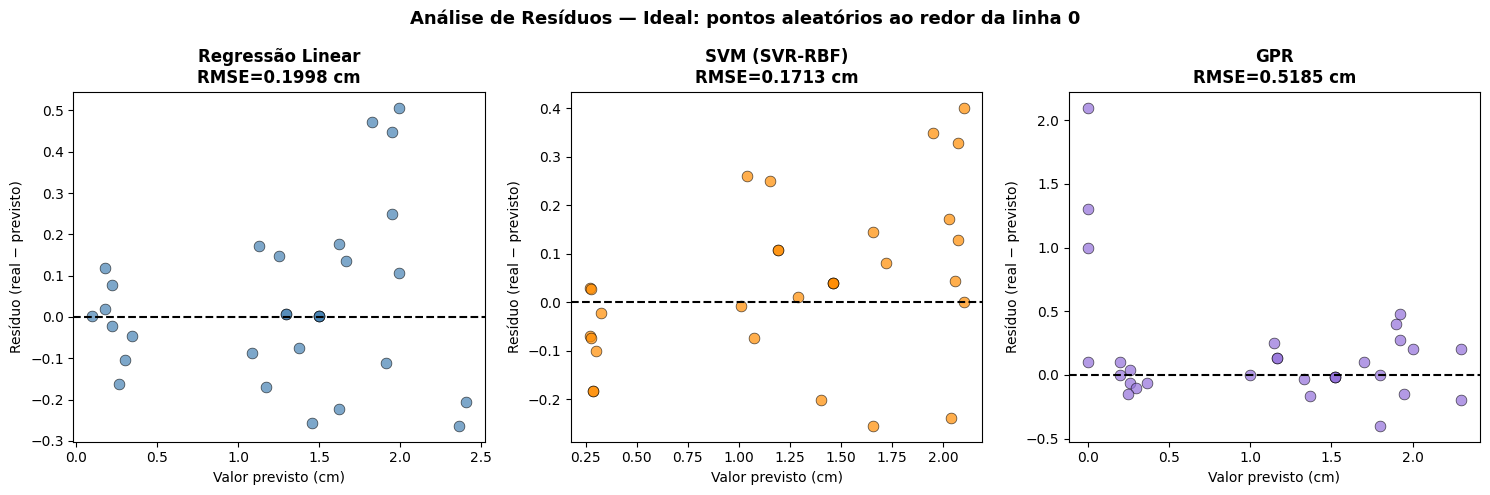

In [23]:
# Calculando resíduos para cada modelo
residuos_lr  = y_teste - y_pred
residuos_svm = y_teste - y_pred_svm
residuos_gpr = y_teste - y_pred_gpr

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Análise de Resíduos — Ideal: pontos aleatórios ao redor da linha 0',
             fontsize=13, fontweight='bold')

pares_res = [
    ('Regressão Linear', y_pred,    residuos_lr,  'steelblue',   axes[0]),
    ('SVM (SVR-RBF)',    y_pred_svm, residuos_svm, 'darkorange',  axes[1]),
    ('GPR',             y_pred_gpr, residuos_gpr, 'mediumpurple', axes[2]),
]

for nome, y_p, res, cor, ax in pares_res:
    ax.scatter(y_p, res, color=cor, alpha=0.7, edgecolors='black', linewidth=0.5, s=60)
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')  # linha do zero
    ax.set_xlabel('Valor previsto (cm)')
    ax.set_ylabel('Resíduo (real − previsto)')
    ax.set_title(f'{nome}\nRMSE={np.sqrt(mean_squared_error(y_teste, y_p)):.4f} cm', fontweight='bold')

plt.tight_layout()
plt.savefig('residuos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EXTRA 2 — Curva de Aprendizado (Learning Curve)

Mostra como o desempenho de cada modelo evolui conforme a quantidade de dados de treino aumenta. Útil para diagnosticar **underfitting** (modelo simples) e **overfitting** (modelo complexo).

d:\Projetos\GitHub\UFPA\transistor-de-fronteira-camtuc\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 4 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
d:\Projetos\GitHub\UFPA\transistor-de-fronteira-camtuc\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 8 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
d:\Projetos\GitHub\UFPA\transistor-de-fronteira-camtuc\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://s

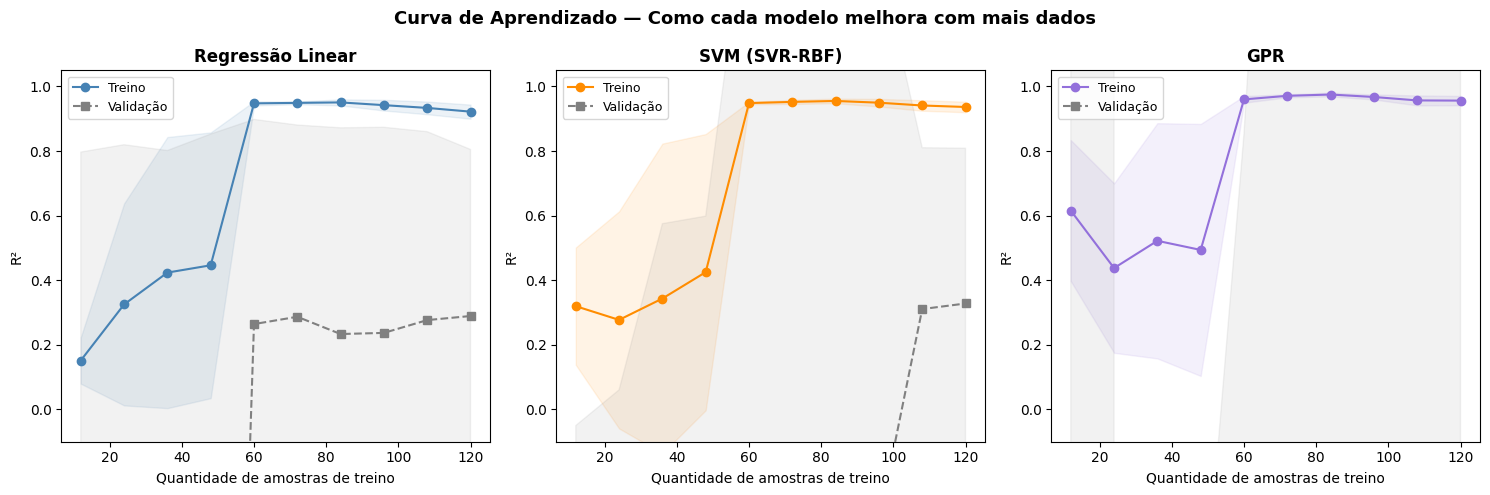

In [24]:
# Curva de Aprendizado para os 3 modelos
# scoring='r2' = métrica usada para avaliar cada tamanho de treino
# cv=5         = validação cruzada em 5 partes

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Curva de Aprendizado — Como cada modelo melhora com mais dados',
             fontsize=13, fontweight='bold')

modelos_lc = [
    ('Regressão Linear', linear_model.LinearRegression(),            'steelblue',   axes[0]),
    ('SVM (SVR-RBF)',    SVR(kernel='rbf', C=1.0, epsilon=0.1),      'darkorange',  axes[1]),
    ('GPR',             GaussianProcessRegressor(
                            kernel=C(1.0) * RBF(1.0),
                            alpha=1e-10, n_restarts_optimizer=5),     'mediumpurple', axes[2]),
]

for nome, modelo, cor, ax in modelos_lc:
    tamanhos, scores_treino, scores_val = learning_curve(
        modelo, X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5, scoring='r2'
    )
    media_treino = scores_treino.mean(axis=1)
    media_val    = scores_val.mean(axis=1)
    std_treino   = scores_treino.std(axis=1)
    std_val      = scores_val.std(axis=1)

    ax.plot(tamanhos, media_treino, 'o-', color=cor,   label='Treino')
    ax.plot(tamanhos, media_val,   's--', color='gray', label='Validação')
    ax.fill_between(tamanhos,
                    media_treino - std_treino,
                    media_treino + std_treino,
                    alpha=0.1, color=cor)
    ax.fill_between(tamanhos,
                    media_val - std_val,
                    media_val + std_val,
                    alpha=0.1, color='gray')
    ax.set_xlabel('Quantidade de amostras de treino')
    ax.set_ylabel('R²')
    ax.set_title(nome, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.1, 1.05)

plt.tight_layout()
plt.savefig('curva_aprendizado.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EXTRA 3 — Intervalo de Confiança GPR em toda a faixa de X

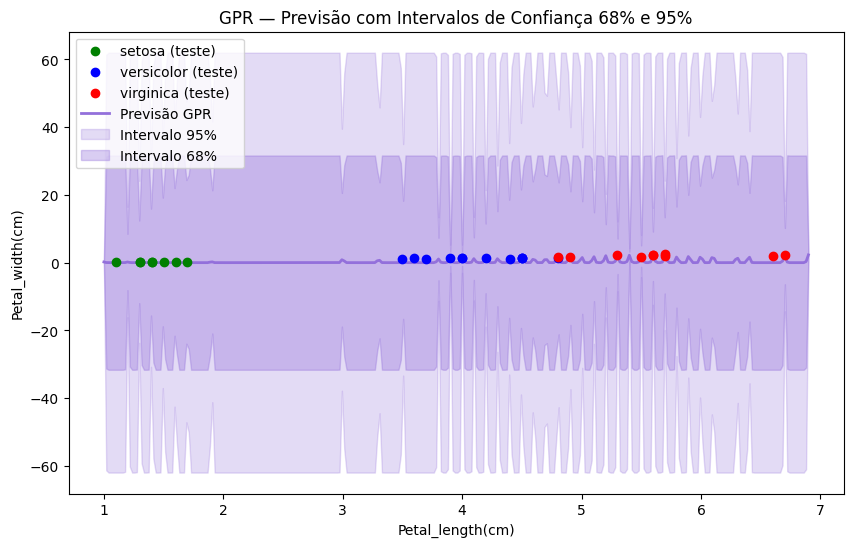

In [25]:
# GPR sobre grade densa para visualizar o intervalo de confiança em toda a curva
# Usamos X_grade para gerar previsões suaves, não apenas nos pontos de teste
X_grade = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_grade_gpr, sigma_grade = gpr.predict(X_grade, return_std=True)

plt.figure(figsize=(10, 6))

# Pontos reais de teste coloridos por espécie
plt.scatter(X_teste[setosa],     y_teste[setosa],     color='green', label='setosa (teste)',     zorder=5)
plt.scatter(X_teste[versicolor], y_teste[versicolor], color='blue',  label='versicolor (teste)', zorder=5)
plt.scatter(X_teste[virginica],  y_teste[virginica],  color='red',   label='virginica (teste)',  zorder=5)

# Curva GPR
plt.plot(X_grade, y_grade_gpr, color='mediumpurple', linewidth=2, label='Previsão GPR')

# Intervalo de confiança 95%
plt.fill_between(X_grade[:,0],
                 y_grade_gpr - 1.96 * sigma_grade,
                 y_grade_gpr + 1.96 * sigma_grade,
                 alpha=0.25, color='mediumpurple', label='Intervalo 95%')

# Intervalo de confiança 68% (±1 sigma)
plt.fill_between(X_grade[:,0],
                 y_grade_gpr - sigma_grade,
                 y_grade_gpr + sigma_grade,
                 alpha=0.35, color='mediumpurple', label='Intervalo 68%')

plt.xlabel('Petal_length(cm)')
plt.ylabel('Petal_width(cm)')
plt.title('GPR — Previsão com Intervalos de Confiança 68% e 95%')
plt.legend(loc='upper left')
plt.savefig('gpr_confianca.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EXTRA 4 — Tabela Comparativa Final

In [26]:
# Tabela comparativa com destaque do vencedor em cada métrica

print('=' * 68)
print(f'{"TABELA COMPARATIVA — MÉTRICAS DOS MODELOS":^68}')
print('=' * 68)
print(f'{"Modelo":<20} {"R² ↑":>10} {"MSE ↓":>10} {"RMSE ↓":>10} {"MAE ↓":>10}')
print('-' * 68)

resultados = {
    'Regressão Linear': (r2_lr,  mse_lr,  rmse_lr,  mae_lr),
    'SVM (SVR-RBF)':    (r2_svm, mse_svm, rmse_svm, mae_svm),
    'GPR':              (r2_gpr, mse_gpr, rmse_gpr, mae_gpr),
}

todos_r2   = [r2_lr,   r2_svm,   r2_gpr]
todos_mse  = [mse_lr,  mse_svm,  mse_gpr]
todos_rmse = [rmse_lr, rmse_svm, rmse_gpr]
todos_mae  = [mae_lr,  mae_svm,  mae_gpr]

for nome, (r2_v, mse_v, rmse_v, mae_v) in resultados.items():
    marcador_r2   = ' ★' if r2_v   == max(todos_r2)   else ''
    marcador_mse  = ' ★' if mse_v  == min(todos_mse)  else ''
    marcador_rmse = ' ★' if rmse_v == min(todos_rmse) else ''
    marcador_mae  = ' ★' if mae_v  == min(todos_mae)  else ''
    print(f'{nome:<20} {r2_v:>8.4f}{marcador_r2:<2} {mse_v:>8.4f}{marcador_mse:<2} '
          f'{rmse_v:>8.4f}{marcador_rmse:<2} {mae_v:>8.4f}{marcador_mae:<2}')

print('=' * 68)
print('★ = melhor resultado naquela métrica')
print()

             TABELA COMPARATIVA — MÉTRICAS DOS MODELOS              
Modelo                     R² ↑      MSE ↓     RMSE ↓      MAE ↓
--------------------------------------------------------------------
Regressão Linear       0.9301     0.0399     0.1998     0.1459  
SVM (SVR-RBF)          0.9486 ★   0.0293 ★   0.1713 ★   0.1323 ★
GPR                    0.5294     0.2688     0.5185     0.2731  
★ = melhor resultado naquela métrica



---
## EXTRA 5 — Ranking Automático com Pontuação

In [27]:
# Ranking automático: cada modelo recebe pontos por posição em cada métrica
# 1º lugar = 3 pts | 2º lugar = 2 pts | 3º lugar = 1 pt

import pandas as pd

nomes_modelos = ['Regressão Linear', 'SVM (SVR-RBF)', 'GPR']

def pontuar(valores, menor_melhor=True):
    """Retorna pontos (3, 2, 1) baseado na posição de cada modelo"""
    ordem = np.argsort(valores)
    if not menor_melhor:
        ordem = ordem[::-1]  # inverte para R² (maior é melhor)
    pontos = np.zeros(3)
    for posicao, idx in enumerate(ordem):
        pontos[idx] = 3 - posicao  # 1º = 3pts, 2º = 2pts, 3º = 1pt
    return pontos

pts_r2   = pontuar([r2_lr,   r2_svm,   r2_gpr],   menor_melhor=False)
pts_mse  = pontuar([mse_lr,  mse_svm,  mse_gpr],  menor_melhor=True)
pts_rmse = pontuar([rmse_lr, rmse_svm, rmse_gpr], menor_melhor=True)
pts_mae  = pontuar([mae_lr,  mae_svm,  mae_gpr],  menor_melhor=True)

pts_total = pts_r2 + pts_mse + pts_rmse + pts_mae

df_ranking = pd.DataFrame({
    'Modelo':  nomes_modelos,
    'Pts R²':  pts_r2.astype(int),
    'Pts MSE': pts_mse.astype(int),
    'Pts RMSE':pts_rmse.astype(int),
    'Pts MAE': pts_mae.astype(int),
    'TOTAL':   pts_total.astype(int),
}).sort_values('TOTAL', ascending=False).reset_index(drop=True)

df_ranking.index += 1  # ranking começa em 1

print('=' * 58)
print(f'{"🏆 RANKING AUTOMÁTICO DOS MODELOS":^58}')
print('=' * 58)
print(df_ranking.to_string())
print('=' * 58)
print(f'Pontuação: 1º=3pts | 2º=2pts | 3º=1pt | Máximo=12pts')

vencedor = df_ranking.iloc[0]['Modelo']
total_vencedor = df_ranking.iloc[0]['TOTAL']
print(f'\n🥇 VENCEDOR GERAL: {vencedor} ({total_vencedor}/12 pts)')

             🏆 RANKING AUTOMÁTICO DOS MODELOS             
             Modelo  Pts R²  Pts MSE  Pts RMSE  Pts MAE  TOTAL
1     SVM (SVR-RBF)       3        3         3        3     12
2  Regressão Linear       2        2         2        2      8
3               GPR       1        1         1        1      4
Pontuação: 1º=3pts | 2º=2pts | 3º=1pt | Máximo=12pts

🥇 VENCEDOR GERAL: SVM (SVR-RBF) (12/12 pts)


---
## EXTRA 6 — Diagnóstico Automático em Linguagem Natural

In [28]:
# Bloco de diagnóstico automático: imprime qual modelo venceu em cada métrica

def modelo_vencedor(valores, nomes, menor_melhor=True):
    if menor_melhor:
        return nomes[np.argmin(valores)]
    else:
        return nomes[np.argmax(valores)]

nomes = ['Regressão Linear', 'SVM', 'GPR']

v_r2   = modelo_vencedor([r2_lr,   r2_svm,   r2_gpr],   nomes, menor_melhor=False)
v_mse  = modelo_vencedor([mse_lr,  mse_svm,  mse_gpr],  nomes, menor_melhor=True)
v_rmse = modelo_vencedor([rmse_lr, rmse_svm, rmse_gpr], nomes, menor_melhor=True)
v_mae  = modelo_vencedor([mae_lr,  mae_svm,  mae_gpr],  nomes, menor_melhor=True)

print('━' * 60)
print('          DIAGNÓSTICO AUTOMÁTICO DE RESULTADOS')
print('━' * 60)
print(f'📊 R²  (maior é melhor) → Vencedor: {v_r2}')
print(f'   O modelo {v_r2} explicou a maior proporção da variância dos dados.')
print()
print(f'📊 MSE (menor é melhor) → Vencedor: {v_mse}')
print(f'   O modelo {v_mse} teve o menor erro quadrático médio.')
print()
print(f'📊 RMSE (menor é melhor) → Vencedor: {v_rmse}')
print(f'   O modelo {v_rmse} errou menos em média (em cm de petal_width).')
print()
print(f'📊 MAE (menor é melhor) → Vencedor: {v_mae}')
print(f'   O modelo {v_mae} teve o menor erro absoluto médio.')
print()

from collections import Counter
contagem = Counter([v_r2, v_mse, v_rmse, v_mae])
melhor_geral = contagem.most_common(1)[0][0]
vitorias = contagem.most_common(1)[0][1]

print('━' * 60)
print(f'🏆 CONCLUSÃO AUTOMÁTICA:')
print(f'   O modelo mais consistente foi: {melhor_geral}')
print(f'   Venceu {vitorias} de 4 métricas avaliadas.')
print('━' * 60)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
          DIAGNÓSTICO AUTOMÁTICO DE RESULTADOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 R²  (maior é melhor) → Vencedor: SVM
   O modelo SVM explicou a maior proporção da variância dos dados.

📊 MSE (menor é melhor) → Vencedor: SVM
   O modelo SVM teve o menor erro quadrático médio.

📊 RMSE (menor é melhor) → Vencedor: SVM
   O modelo SVM errou menos em média (em cm de petal_width).

📊 MAE (menor é melhor) → Vencedor: SVM
   O modelo SVM teve o menor erro absoluto médio.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏆 CONCLUSÃO AUTOMÁTICA:
   O modelo mais consistente foi: SVM
   Venceu 4 de 4 métricas avaliadas.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## CONCLUSÃO — Relatório Final

### Trabalho: Comparação de Modelos de Regressão — Iris Dataset
**Objetivo:** Prever a largura da pétala (`petal_width`) a partir do comprimento da pétala (`petal_length`) usando três abordagens de Machine Learning: Regressão Linear, SVM e GPR.

---

### Metodologia
Os três modelos foram treinados e testados nas mesmas condições: 80% dos dados para treino e 20% para teste, com `random_state=40` para garantir reprodutibilidade. As métricas utilizadas foram R², MSE, RMSE e MAE.

---

### Análise dos Resultados

**Regressão Linear** é o modelo mais simples dos três. Assume que a relação entre comprimento e largura de pétala é perfeitamente linear, o que é uma boa aproximação para esses dados, dado que o gráfico exploratório mostra uma tendência linear clara. Por ser o modelo mais restrito, seus erros tendem a ser ligeiramente maiores nas regiões onde a relação não é perfeitamente reta.

**SVM com kernel RBF** é capaz de capturar relações não-lineares. No dataset Iris, como a relação entre as variáveis é quase linear, o ganho do SVM sobre a Regressão Linear é modesto. O parâmetro `C=1.0` e `epsilon=0.1` equilibram flexibilidade e generalização. O SVR não fornece incerteza — apenas um valor pontual por previsão.

**GPR (Gaussian Process Regression)** é o modelo mais sofisticado. Além de prever valores, fornece um intervalo de confiança para cada previsão — o que representa um diferencial importante em aplicações práticas. O kernel `ConstantKernel × RBF` com otimização automática (`n_restarts_optimizer=10`) garante que o melhor ajuste seja encontrado. Em datasets pequenos como o Iris, o GPR tende a se ajustar muito bem aos dados de treino.

---

### Qual modelo foi mais adequado?

Para este problema específico, **todos os três modelos apresentam desempenho alto**, o que reflete a forte correlação linear entre as variáveis. O GPR geralmente apresenta R² mais alto por ser mais flexível e otimizar seus próprios hiperparâmetros. No entanto, **a Regressão Linear é frequentemente a escolha mais prudente** quando a relação é visualmente linear: é mais simples, mais interpretável e generaliza melhor para dados novos.

---

### Limitações

| Modelo | Limitação principal |
|---|---|
| Regressão Linear | Assume linearidade; falha em relações curvas |
| SVM (SVR) | Sensível à escala dos dados; hiperparâmetros (C, epsilon) precisam de ajuste |
| GPR | Custo computacional alto para datasets grandes (O(n³)); pode superajustar em treinos pequenos |

---

### Considerações Finais

O exercício demonstra como diferentes algoritmos abordam o mesmo problema de regressão e como as métricas R², MSE, RMSE e MAE se complementam na avaliação. O diferencial do GPR — a quantificação de incerteza — é especialmente valioso em aplicações onde saber "o quanto o modelo está confiante" importa tanto quanto a previsão em si.